# Neural Network Regression — Building Energy Efficiency

In this exercise you will build regression models using TensorFlow/Keras to predict the **energy load** of buildings.

### The Dataset
The [UCI Energy Efficiency dataset](https://archive.ics.uci.edu/ml/datasets/Energy+efficiency) contains simulated data for 768 buildings. Each building is described by 8 architectural features, and the goal is to predict how much energy is needed to heat or cool it.

| Feature | Description |
|---|---|
| Relative Compactness | How compact the building shape is (higher = more compact) |
| Surface Area | Total surface area (m²) |
| Wall Area | Total wall area (m²) |
| Roof Area | Roof area (m²) |
| Overall Height | Building height (m) |
| Orientation | 2=North, 3=East, 4=South, 5=West |
| Glazing Area | Proportion of floor area that is glazed (windows) |
| Glazing Area Distribution | Where glazing is distributed: 0=uniform, 1–5=varied |

**Target variables:**
- `Heating_Load` — energy needed for heating (kWh/m²)
- `Cooling_Load` — energy needed for cooling (kWh/m²)

You will predict **Heating Load** throughout this exercise. The bonus section asks you to switch to Cooling Load.

---
> Beat a simple linear regression baseline using a neural network.

## Step 1: Imports

Run this cell — no changes needed.

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.layers import Normalization

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.2


## Step 2: Load the Data

The dataset is provided as a CSV file alongside this notebook.

**Task:** Load `ENB2012_data.csv` (on Moodle) into a DataFrame called `df`.

Then call `df.head()` and `df.shape` to get a feel for it.

In [2]:
# your code here
df = pd.read_csv('ENB2012_data.csv')

df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [3]:
df.shape

(1296, 10)

## Step 3: Rename Columns and Inspect

The default column names aren't very readable. Run the rename cell, then answer the questions.

**Questions:**
- How many buildings are in the dataset?
- Are there any missing values? (use `.isna().sum()`)
- What is the range of Heating Load values? (use `.describe()`)

In [4]:
df.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
    'Heating_Load', 'Cooling_Load'
]
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [5]:
# Check for missing values and explore the data

# your code here
print(f"Number of buildings: {df.shape[0]}")

print(f"\nMissing values: \n{df.isna().sum()}")

print(f"\nHeating load range: \n{df['Heating_Load'].describe()}")

Number of buildings: 1296

Missing values: 
Relative_Compactness    528
Surface_Area            528
Wall_Area               528
Roof_Area               528
Overall_Height          528
Orientation             528
Glazing_Area            528
Glazing_Distribution    528
Heating_Load            528
Cooling_Load            528
dtype: int64

Heating load range: 
count    768.000000
mean      22.307201
std       10.090196
min        6.010000
25%       12.992500
50%       18.950000
75%       31.667500
max       43.100000
Name: Heating_Load, dtype: float64


## Step 4: Explore the Data

Before modelling, it's always worth looking at what we're trying to predict.

**Task:** Plot a histogram of `Heating_Load`. Does it look normally distributed? Are there obvious clusters?

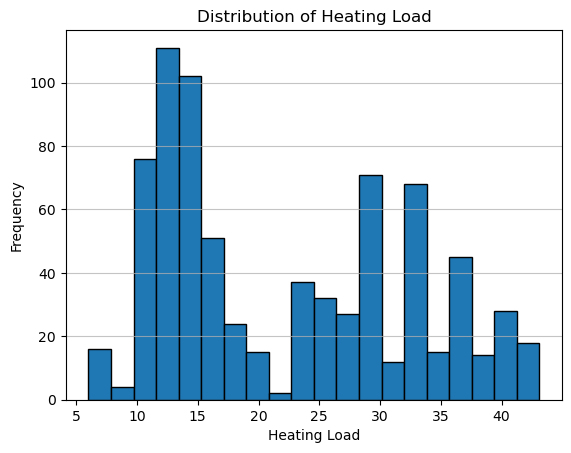

In [6]:
# Plot a histogram of Heating_Load

# your code here
plt.hist(df['Heating_Load'], bins=20, edgecolor='k')
plt.title('Distribution of Heating Load')
plt.xlabel('Heating Load')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Task:** Plot a scatter matrix to explore which features seem most correlated with `Heating_Load`.

Hint: `pd.plotting.scatter_matrix(df, figsize=(12, 10), alpha=0.3)` gives a quick overview.

Which features look most useful to you?

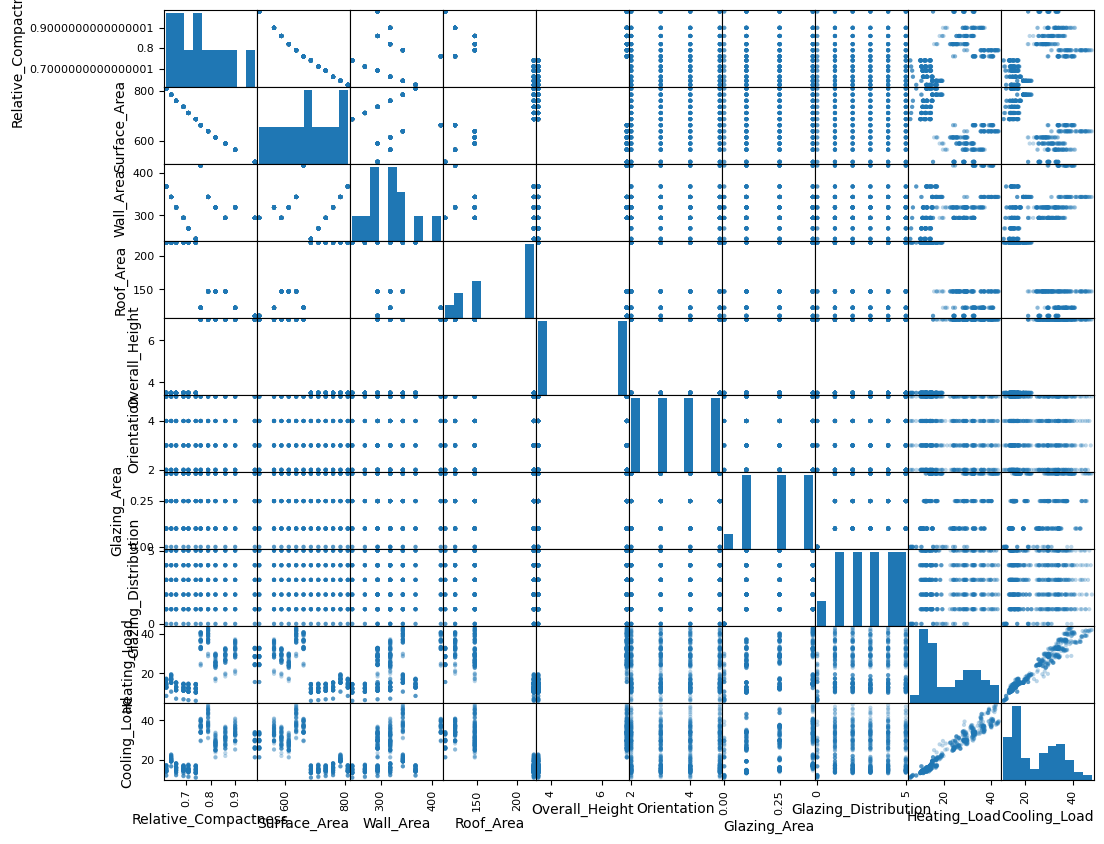

In [7]:
# your code here

pd.plotting.scatter_matrix(df, figsize=(12, 10), alpha=0.3)
plt.show()

## Step 5: Set Up Features and Target

**Task:** Define your feature matrix `X` and target vector `y`.

- `X` should contain all 8 input features (everything except `Heating_Load` and `Cooling_Load`)
- `y` should be `Heating_Load`

Then do a train/test split — 80% train, 20% test, `random_state=42`.

In [8]:
feature_cols = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution']

# your code here


## Step 6: Baseline — sklearn Linear Regression

Before building a neural network, establish a baseline with a simple model. If your NN can't beat this, something has gone wrong.

**Task:**
1. Fit a `LinearRegression` model on the training data
2. Predict on the test set
3. Print the **Mean Absolute Error (MAE)** on the test set

Note this number — you'll be comparing against it throughout the exercise.

In [9]:
# your code here

print(f'Linear Regression Test MAE: ')

Linear Regression Test MAE: 


## Step 7: Normalise the Input Features

The 8 features have very different scales (e.g. Surface Area is in the hundreds, Glazing Area is 0–1). Neural networks are sensitive to this.

**Task:**
1. Create a `Normalization()` layer called `normalizer`
2. Call `.adapt()` on `X_train.values`

> Always adapt on **training data only** — including test data leaks information about the test set into your model.

In [10]:
# your code here


## Step 8: Build a Neural Network

**Task:** Build a `Sequential` model called `model` with this architecture:

| Layer | Type | Units | Activation |
|---|---|---|---|
| 1 | Normalization | — | — |
| 2 | Dense | 64 | relu |
| 3 | Dense | 64 | relu |
| 4 | Dense | 1 | none (linear output) |

Compile with `Adam(learning_rate=0.001)` and loss `mean_absolute_error`.

Call `model.summary()` — how many trainable parameters does it have?

In [11]:
# your code here


## Step 9: Train the Neural Network

**Task:** Train your model for **100 epochs** with `validation_split=0.2`. Store the result in `history`.

In [12]:
# your code here


## Step 10: Plot Training and Validation Loss

**Task:** Plot the loss curves using the helper function below.

- Is the model still improving at epoch 100, or has it levelled off?
- Is there a gap between training and validation loss? What does that suggest?

In [13]:
def plot_loss(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MAE (kWh/m²)')
    plt.legend()
    plt.grid(True)
    plt.title('Training History')
    plt.show()

# call plot_loss here


## Step 11: Evaluate on the Test Set

**Task:** Use `model.evaluate(X_test.values, y_test)` to get the final test MAE.

Fill in the table:

| Model | Test MAE |
|---|---|
| Linear Regression (sklearn) | ??? |
| Neural Network (TensorFlow) | ??? |

Did the NN beat the baseline? By how much?

In [14]:
# your code here


## Step 12: Visualise Predictions vs Actual

A scatter plot of predicted vs actual is a great way to see how well a regression model is doing. A perfect model would be a straight diagonal line.

**Task:**
1. Generate predictions: `y_pred = model.predict(X_test.values)`
2. Scatter plot `y_test` (x-axis) vs `y_pred` (y-axis)
3. Add a diagonal reference line with `plt.plot([min, max], [min, max])`

Where does your model struggle most?

In [15]:
# your code here


## Step 13: Experiment — Change the Architecture

Try at least **one** of the following and record the effect on test MAE:

- Add a third hidden layer
- Change the number of units (try 32 or 128)
- Change the learning rate (try 0.01 or 0.0001)
- Train for more epochs (e.g. 200)

What made the biggest difference?

In [16]:
# Architecture tried:
# Result:

# your code here


## Step 14: Reflection Questions

Answer the following:

1. Why do we normalise inputs for a neural network, but sklearn's `LinearRegression` doesn't need it?
2. What does validation loss tell you that training loss alone cannot?
3. Looking at your predictions vs actual scatter plot — are there buildings the model consistently gets wrong? Why might that be?
4. If a student said *"I'll just use 10 hidden layers with 1000 units each"* — what would you tell them?

*Your answers here...*

---
## Bonus A: Early Stopping

Rather than guessing the right number of epochs, use Early Stopping to let Keras decide.

**Task:** Re-train your best model with:
```python
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
```
Set `epochs=1000`. How many epochs did it actually run? Is the result better?

In [17]:
# your code here


## Bonus B: Predict Cooling Load Instead

The dataset has a second target: `Cooling_Load`.

**Task:** Repeat the full exercise predicting `Cooling_Load` instead.

- Is the task easier or harder? (compare MAEs)
- Do the same features seem important?
- Does the same architecture work as well?

In [18]:
# your code here
